In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

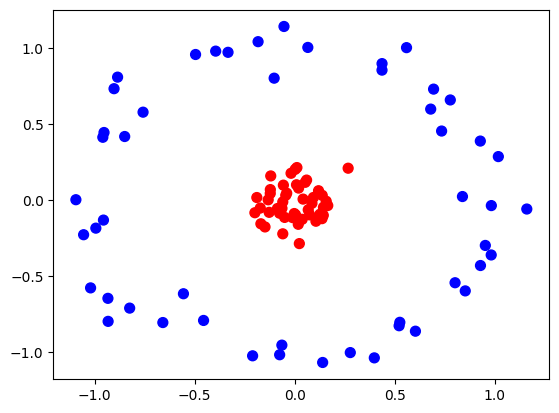

In [6]:
from sklearn.datasets._samples_generator import make_circles

X,y = make_circles(100,factor=.1,noise=.1)
plt.scatter(X[:,0],X[:,1],c=y,s=50,cmap='bwr')

In [7]:
X_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [8]:
classifier = SVC(kernel='linear')
classifier.fit(X_train,y_train)

y_pred = classifier.predict(x_test)


In [9]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.7

In [10]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, 
                                 stop = X_set[:, 0].max() + 1, 
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1, 
                                 stop = X_set[:, 1].max() + 1, 
                                 step = 0.01))
  
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75, 
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

/var/folders/sg/x59phjgd28b4zgd29ltjhgp40000gn/T/ipykernel_28484/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


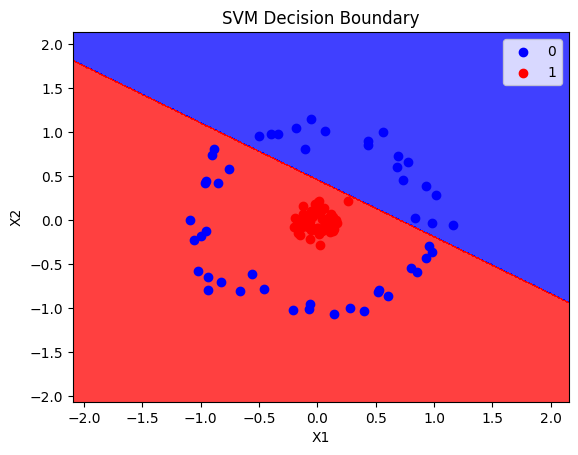

In [11]:
plot_decision_boundary(X, y, classifier)

In [ ]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    # radial basis function
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

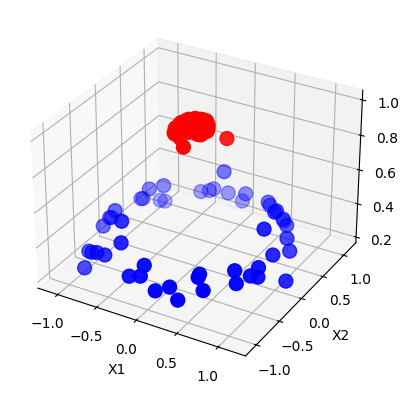

In [13]:
plot_3d_plot(X,y)

In [15]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(x_test)

In [16]:
accuracy_score(y_test, y_pred)

1.0

/var/folders/sg/x59phjgd28b4zgd29ltjhgp40000gn/T/ipykernel_28484/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


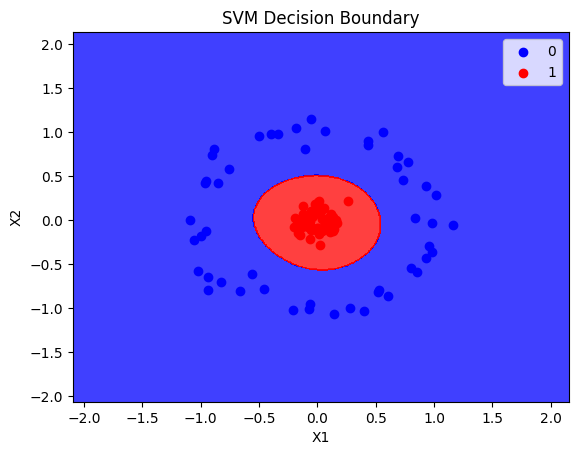

In [17]:
plot_decision_boundary(X, y, rbf_classifier)

In [ ]:
poly_classifier = SVC(kernel="poly")
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(x_test)

In [22]:
accuracy_score(y_test,y_pred)

0.55

/var/folders/sg/x59phjgd28b4zgd29ltjhgp40000gn/T/ipykernel_28484/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


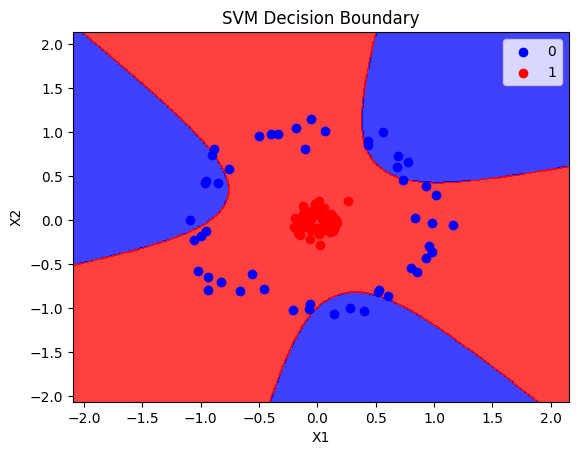

In [23]:
plot_decision_boundary(X, y, poly_classifier)

In [24]:
X

array([[-0.05656834,  0.0998924 ],
       [ 0.92897127, -0.4284477 ],
       [-0.18305882,  1.0432827 ],
       [ 0.01107772,  0.21563077],
       [-0.33332839,  0.97335139],
       [-1.0940562 ,  0.00420728],
       [-0.90331506,  0.73415027],
       [-0.93389676, -0.64417492],
       [-0.05958117, -0.01040902],
       [-0.45564924, -0.78959169],
       [-0.65927524, -0.803375  ],
       [-0.18931815,  0.01857862],
       [ 0.14302147, -0.0980712 ],
       [ 0.52215032, -0.82439623],
       [ 0.06571561,  1.0054553 ],
       [ 0.39813192, -1.03562952],
       [ 0.52574222, -0.8017999 ],
       [ 0.09364114,  0.01894359],
       [-0.93292978, -0.79558298],
       [-0.00214405, -0.08665189],
       [-0.12764091, -0.07874346],
       [ 0.11924812,  0.06330688],
       [-1.05548099, -0.22599799],
       [ 0.68011996,  0.59994351],
       [ 0.95323083, -0.29641057],
       [-0.4956836 ,  0.95900225],
       [ 0.12378858, -0.10824375],
       [ 1.01830062,  0.28772499],
       [-0.95942095,

In [27]:
np.exp(-(X**2)).sum(1)

array([1.98687627, 1.25419547, 1.30378653, 1.95444507, 1.28258511,
       1.30209384, 1.02555152, 1.07841209, 1.99634804, 1.34860782,
       1.17194198, 1.96444823, 1.97018079, 1.26817101, 1.35956741,
       1.19555757, 1.28428015, 1.99091087, 0.94982337, 1.99251497,
       1.97765845, 1.98188077, 1.2784375 , 1.32739126, 1.3189582 ,
       1.18079956, 1.97314486, 1.2750877 , 1.24029496, 1.23738825,
       1.27135673, 1.99689046, 1.99312782, 1.97885386, 1.17161057,
       1.22248185, 1.95456107, 1.96980561, 1.99157225, 1.88735282,
       1.2815247 , 1.99343146, 1.39533387, 1.94835882, 1.94812945,
       1.96844247, 1.37909155, 1.98719417, 1.33924932, 1.98325407,
       1.97587237, 1.98029086, 1.30686495, 1.96825217, 1.18478791,
       1.27729139, 1.419733  , 1.9671599 , 1.39998355, 1.98321896,
       1.97521474, 1.9701192 , 1.11152479, 1.19262648, 1.98013669,
       1.98971543, 1.98531357, 1.9894868 , 1.97746027, 1.2928453 ,
       1.99322505, 1.98311738, 1.38408697, 1.09634092, 1.30167

In [28]:
X_new=np.exp(-(X**2))

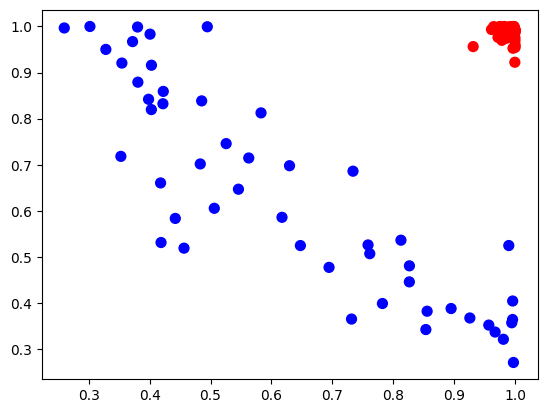

In [29]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')